# 💰 Personal Finance Analysis — EDA
**Dataset:** BudgetWise Personal Finance Dataset (Kaggle)  
**Objetivo:** Limpiar los datos sucios y extraer insights sobre ingresos, gastos y ahorro.

---


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. Carga y diagnóstico inicial

In [11]:
df_raw = pd.read_csv('../data/raw/budgetwise_finance_dataset.csv')

print(f"Shape: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print()
print("Primeras filas:")
df_raw.head(5)


Shape: 15,900 filas × 9 columnas

Primeras filas:


,transaction_id,user_id,date,transaction_type,category,amount,payment_mode,location,notes
0,T4999,U018,2023-04-25,Expense,Educaton,3888,card,Ahmedabad,Movie tickets
1,T12828,U133,08/05/2022,Expense,rent,649,NaN,Hyderabad,asdfgh
2,T7403,U091,31-12-23,Income,Freelance,13239,Csh,BAN,Books
3,T12350,U097,NaN,Expense,Fod,6299,Bank Transfer,AHMEDABAD,Electricity bill
4,T7495,U088,10/28/2022,Expense,entertainment,2287,CARD,Hyderabad,NaN


In [14]:
print("=== TIPOS DE DATOS ===")
print(df_raw.dtypes)
print()
print("=== VALORES NULOS ===")
nulls = df_raw.isnull().sum()
pct   = (nulls / len(df_raw) * 100).round(1)
null_df = pd.DataFrame({'nulos': nulls, '%': pct})
print(null_df[null_df['nulos'] > 0])


=== TIPOS DE DATOS ===
transaction_id      str
user_id             str
date                str
transaction_type    str
category            str
amount              str
payment_mode        str
location            str
notes               str
dtype: object

=== VALORES NULOS ===
              nulos     %
date            486   3.1
category        285   1.8
amount          291   1.8
payment_mode    808   5.1
location       1262   7.9
notes          2821  17.7


In [15]:
print("=== CATEGORÍAS ÚNICAS (sin limpiar) ===")
print(f"Total variantes: {df_raw['category'].nunique()}")
print(sorted(df_raw['category'].dropna().unique()))


=== CATEGORÍAS ÚNICAS (sin limpiar) ===
Total variantes: 46
['Bonus', 'EDU', 'Education', 'Educaton', 'Entertain', 'Entertainment', 'Entrtnmnt', 'FOOD', 'Fod', 'Food', 'Foodd', 'Foods', 'Freelance', 'HEALTH', 'Health', 'Helth', 'Investment', 'Misc', 'OTHERS', 'Other', 'Others', 'RENT', 'Rent', 'Rentt', 'Rnt', 'SAVINGS', 'Salary', 'Saving', 'Savings', 'TRAVEL', 'Traval', 'Travel', 'Travl', 'Utilities', 'Utility', 'Utilties', 'Utlities', 'education', 'entertainment', 'food', 'health', 'others', 'rent', 'savings', 'travel', 'utilities']


## 2. Limpieza de datos

### 2.1 Fechas — 4 formatos distintos


In [16]:
def parse_date(val):
    """Intenta parsear una fecha en cualquiera de los formatos presentes en el dataset."""
    if pd.isna(val):
        return pd.NaT
    val = str(val).strip()
    formats = [
        '%Y-%m-%d',    # 2023-04-25
        '%m/%d/%Y',    # 08/16/2022
        '%d/%m/%Y',    # 08/05/2022
        '%d-%m-%y',    # 13-03-24
        '%d-%m-%Y',    # 31-12-2023
        '%Y-%m-%d',    # 2024-12-12
    ]
    for fmt in formats:
        try:
            return pd.to_datetime(val, format=fmt)
        except:
            pass
    try:
        return pd.to_datetime(val, infer_datetime_format=True)
    except:
        return pd.NaT

df = df_raw.copy()
df['date'] = df['date'].apply(parse_date)

total   = len(df)
parsed  = df['date'].notna().sum()
failed  = df['date'].isna().sum()
print(f"✅ Fechas parseadas: {parsed:,} / {total:,}  ({parsed/total*100:.1f}%)")
print(f"❌ No parseadas (NaT): {failed:,}  ({failed/total*100:.1f}%)")


✅ Fechas parseadas: 15,414 / 15,900  (96.9%)
❌ No parseadas (NaT): 486  (3.1%)


### 2.2 Categorías — normalización de 47 variantes a 10 categorías limpias

In [17]:
CATEGORY_MAP = {
    # Food
    'food': 'Food', 'foods': 'Food', 'fod': 'Food', 'foodd': 'Food', 'FOOD': 'Food',
    # Rent / Housing
    'rent': 'Rent', 'rentt': 'Rent', 'rnt': 'Rent', 'RENT': 'Rent',
    # Utilities
    'utilities': 'Utilities', 'utilties': 'Utilities', 'utlities': 'Utilities',
    'utility': 'Utilities',
    # Entertainment
    'entertainment': 'Entertainment', 'entertain': 'Entertainment',
    'entrtnmnt': 'Entertainment', 'Entertainment': 'Entertainment',
    # Education
    'education': 'Education', 'educaton': 'Education', 'edu': 'Education', 'EDU': 'Education',
    # Health
    'health': 'Health', 'helth': 'Health', 'HEALTH': 'Health',
    # Travel
    'travel': 'Travel', 'travl': 'Travel', 'traval': 'Travel', 'TRAVEL': 'Travel',
    # Savings
    'savings': 'Savings', 'saving': 'Savings', 'SAVINGS': 'Savings',
    # Income sources
    'salary': 'Salary', 'freelance': 'Freelance', 'bonus': 'Bonus',
    'investment': 'Investment',
    # Others
    'others': 'Others', 'other': 'Others', 'misc': 'Others', 'OTHERS': 'Others',
}

def normalize_category(val):
    if pd.isna(val):
        return 'Unknown'
    val_clean = str(val).strip()
    # Buscar por lowercase
    mapped = CATEGORY_MAP.get(val_clean)
    if mapped:
        return mapped
    mapped = CATEGORY_MAP.get(val_clean.lower())
    if mapped:
        return mapped
    return val_clean.title()

df['category'] = df['category'].apply(normalize_category)
print("Categorías después de normalizar:")
print(df['category'].value_counts())


Categorías después de normalizar:
category
Food             3356
Rent             2712
Travel           1985
Utilities        1589
Entertainment    1335
Education        1036
Others            740
Health            623
Freelance         490
Investment        482
Bonus             442
Salary            430
Savings           395
Unknown           285
Name: count, dtype: int64


### 2.3 Amount — limpiar símbolos de moneda y convertir a numérico

In [18]:
def clean_amount(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace('$', '').replace('₹', '').replace('Rs.', '').replace(',', '').strip()
    try:
        return float(val)
    except:
        return np.nan

df['amount'] = df['amount'].apply(clean_amount)
print(f"Amounts válidos: {df['amount'].notna().sum():,}")
print(f"Amounts nulos:   {df['amount'].isna().sum():,}")
print()
print(df['amount'].describe())


Amounts válidos: 15,297
Amounts nulos:   603

count    1.529700e+04
mean     5.381747e+06
std      7.302001e+07
min     -1.000000e+03
25%      2.864000e+03
50%      5.930000e+03
75%      9.556000e+03
max      1.000000e+09
Name: amount, dtype: float64


### 2.4 Payment mode — estandarizar

In [19]:
PAYMENT_MAP = {
    'cash': 'Cash', 'csh': 'Cash', 'CASH': 'Cash',
    'card': 'Card', 'CARD': 'Card', 'debit': 'Card', 'credit': 'Card',
    'upi': 'UPI', 'UPI': 'UPI',
    'bank transfer': 'Bank Transfer', 'transfer': 'Bank Transfer',
}

def normalize_payment(val):
    if pd.isna(val):
        return 'Unknown'
    val_clean = str(val).strip()
    return PAYMENT_MAP.get(val_clean, PAYMENT_MAP.get(val_clean.lower(), val_clean.title()))

df['payment_mode'] = df['payment_mode'].apply(normalize_payment)
print(df['payment_mode'].value_counts())


payment_mode
Cash             3799
UPI              3660
Card             2344
Bank Transfer    1533
Crd              1510
Unknown           808
Bank Transfr      784
Banktransfer      733
Bank_Transfer     729
Name: count, dtype: int64


### 2.5 Eliminar filas sin fecha o amount válido

In [20]:
df_clean = df.dropna(subset=['date', 'amount']).copy()

# Extraer campos temporales útiles
df_clean['year']       = df_clean['date'].dt.year
df_clean['month']      = df_clean['date'].dt.month
df_clean['month_name'] = df_clean['date'].dt.strftime('%b')
df_clean['year_month'] = df_clean['date'].dt.to_period('M')

print(f"Filas originales: {len(df_raw):,}")
print(f"Filas después de limpieza: {len(df_clean):,}")
print(f"Filas eliminadas: {len(df_raw) - len(df_clean):,}")
print()
print(f"Período: {df_clean['date'].min().date()} → {df_clean['date'].max().date()}")


Filas originales: 15,900
Filas después de limpieza: 14,830
Filas eliminadas: 1,070

Período: 2021-01-01 → 2024-12-31


### 2.6 Guardar dataset limpio

In [21]:
import os
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/finance_clean.csv', index=False)
print("✅ Dataset limpio guardado en data/processed/finance_clean.csv")


✅ Dataset limpio guardado en data/processed/finance_clean.csv


---
## 3. Análisis Exploratorio (EDA)

### 3.1 Distribución general: Income vs Expense

In [23]:
summary = df_clean.groupby('transaction_type')['amount'].agg(['sum', 'count', 'mean']).round(2)
summary.columns = ['Total ($)', 'Transacciones', 'Promedio ($)']
print(summary)


                     Total ($)  Transacciones  Promedio ($)
transaction_type                                           
Expense           8.017012e+10          12595    6365233.95
Income            1.468405e+08           2235      65700.45


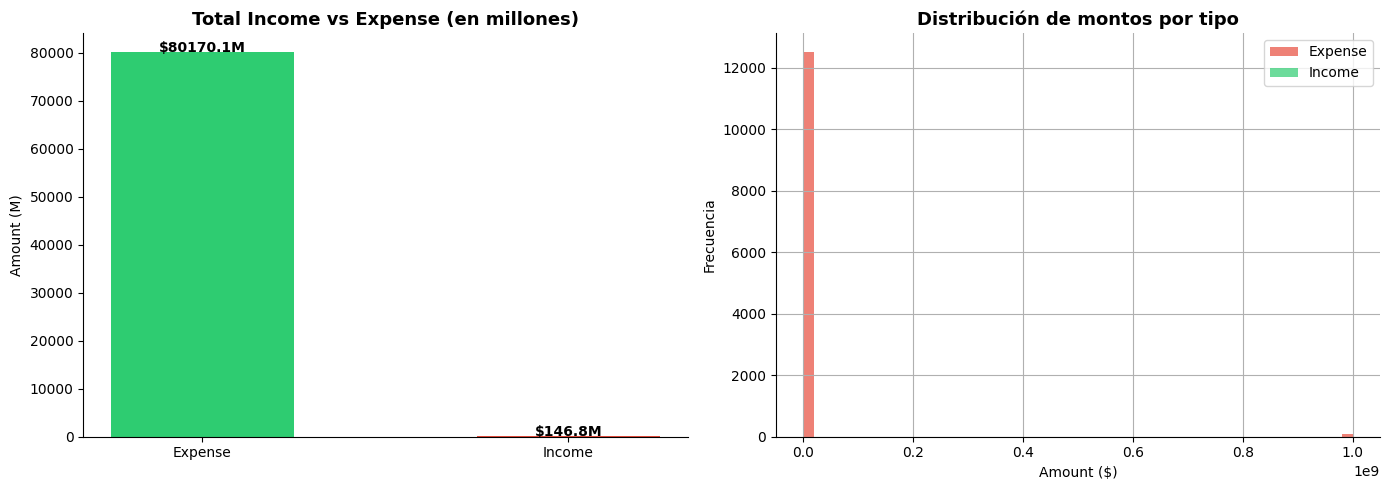

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Total por tipo
totals = df_clean.groupby('transaction_type')['amount'].sum() / 1e6
bars = axes[0].bar(totals.index, totals.values, color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Total Income vs Expense (en millones)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount (M)')
for bar, val in zip(bars, totals.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'${val:.1f}M', ha='center', fontweight='bold')

# Gráfica 2: Distribución de montos
df_clean[df_clean['transaction_type'] == 'Expense']['amount'].hist(
    bins=50, ax=axes[1], color='#e74c3c', alpha=0.7, label='Expense')
df_clean[df_clean['transaction_type'] == 'Income']['amount'].hist(
    bins=50, ax=axes[1], color='#2ecc71', alpha=0.7, label='Income')
axes[1].set_title('Distribución de montos por tipo', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/img/01_income_vs_expense.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.2 Top categorías de gasto

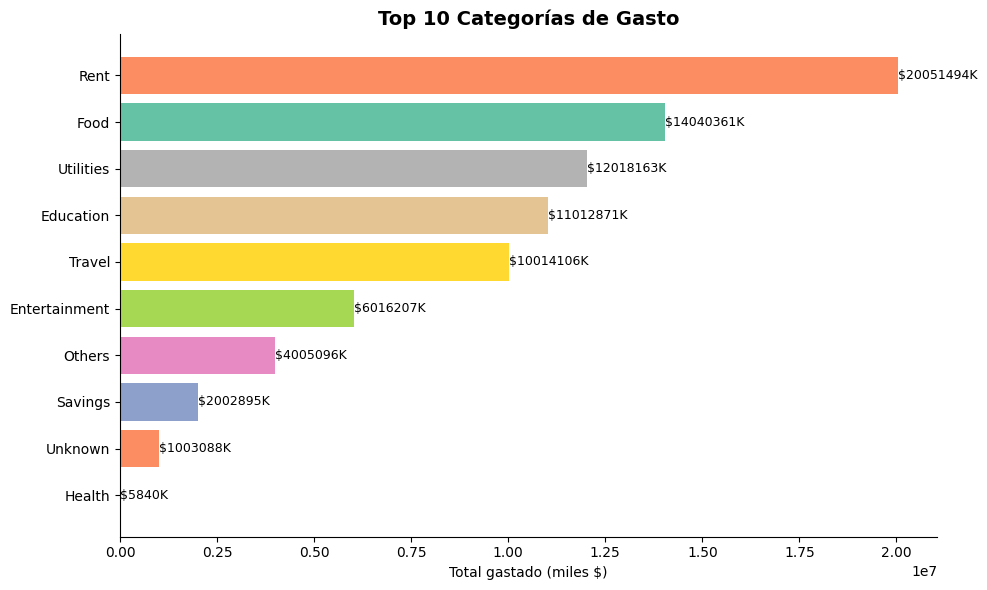

In [25]:
expenses = df_clean[df_clean['transaction_type'] == 'Expense']
top_cats = expenses.groupby('category')['amount'].sum().sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_cats.index, top_cats.values / 1000, color=sns.color_palette("Set2", len(top_cats)))
ax.set_title('Top 10 Categorías de Gasto', fontsize=14, fontweight='bold')
ax.set_xlabel('Total gastado (miles $)')
for bar, val in zip(bars, top_cats.values / 1000):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'${val:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/img/02_top_categories.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Tendencia mensual — Income vs Expense

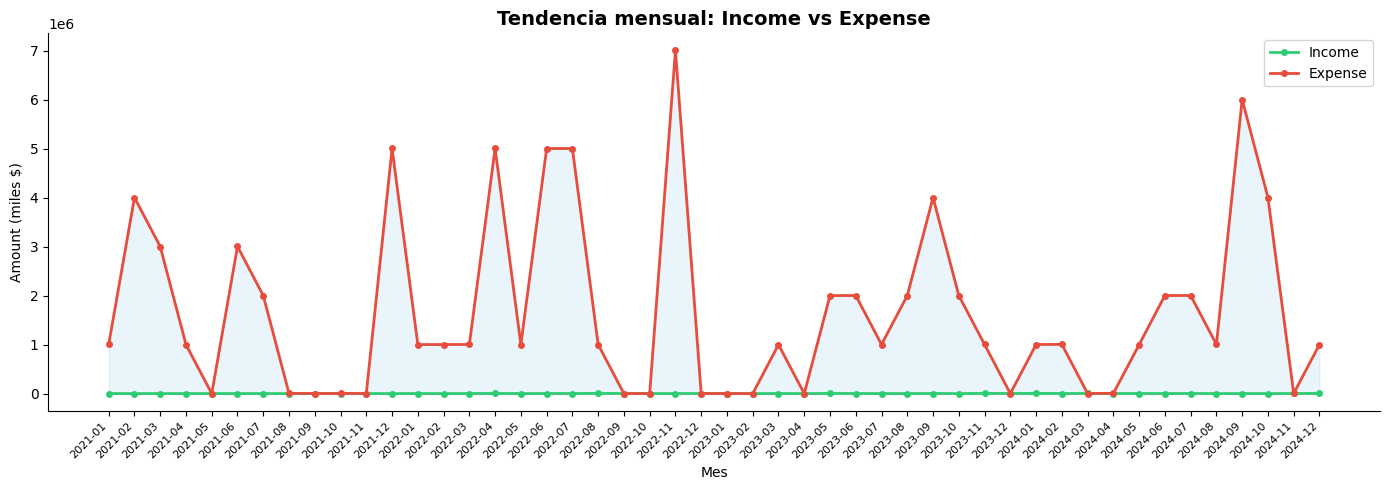

In [26]:
monthly = df_clean.groupby(['year_month', 'transaction_type'])['amount'].sum().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly.index, monthly.get('Income', 0) / 1000,
        marker='o', color='#2ecc71', linewidth=2, label='Income', markersize=4)
ax.plot(monthly.index, monthly.get('Expense', 0) / 1000,
        marker='o', color='#e74c3c', linewidth=2, label='Expense', markersize=4)
ax.fill_between(monthly.index,
                monthly.get('Income', 0) / 1000,
                monthly.get('Expense', 0) / 1000,
                alpha=0.1, color='#3498db')
ax.set_title('Tendencia mensual: Income vs Expense', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Amount (miles $)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../docs/img/03_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Savings Rate mensual

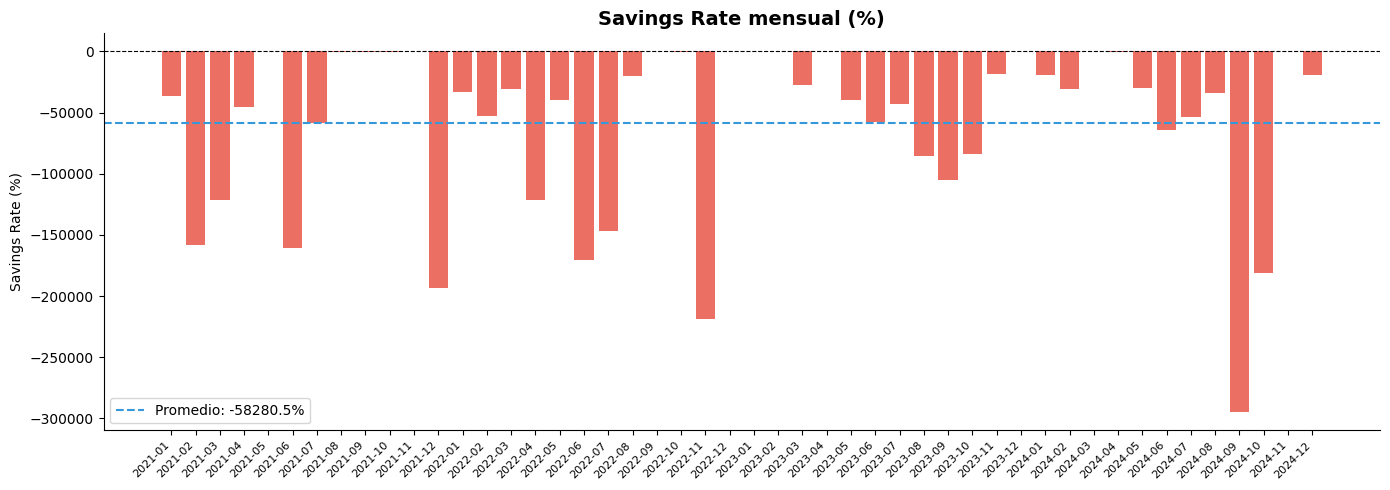

Savings rate promedio: -58280.5%
Mejor mes: 2021-05 (33.1%)
Peor mes:  2024-09 (-294942.0%)


In [27]:
income_m  = df_clean[df_clean['transaction_type'] == 'Income'].groupby('year_month')['amount'].sum()
expense_m = df_clean[df_clean['transaction_type'] == 'Expense'].groupby('year_month')['amount'].sum()

savings_rate = ((income_m - expense_m) / income_m * 100).dropna()
savings_rate.index = savings_rate.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in savings_rate.values]
ax.bar(savings_rate.index, savings_rate.values, color=colors, alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(savings_rate.mean(), color='#3498db', linewidth=1.5,
           linestyle='--', label=f'Promedio: {savings_rate.mean():.1f}%')
ax.set_title('Savings Rate mensual (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Savings Rate (%)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('../docs/img/04_savings_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Savings rate promedio: {savings_rate.mean():.1f}%")
print(f"Mejor mes: {savings_rate.idxmax()} ({savings_rate.max():.1f}%)")
print(f"Peor mes:  {savings_rate.idxmin()} ({savings_rate.min():.1f}%)")


### 3.5 Distribución por método de pago

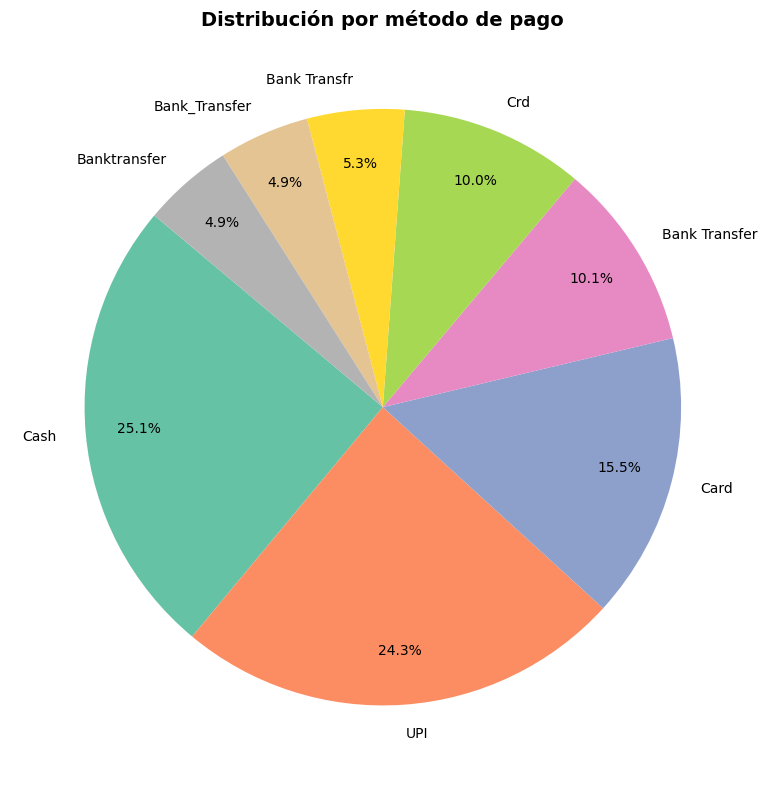

In [28]:
payment_dist = df_clean[df_clean['payment_mode'] != 'Unknown']['payment_mode'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    payment_dist.values,
    labels=payment_dist.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set2", len(payment_dist)),
    startangle=140,
    pctdistance=0.82
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Distribución por método de pago', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/img/05_payment_methods.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Resumen de hallazgos

In [29]:
income_total  = df_clean[df_clean['transaction_type'] == 'Income']['amount'].sum()
expense_total = df_clean[df_clean['transaction_type'] == 'Expense']['amount'].sum()
net_savings   = income_total - expense_total
savings_pct   = net_savings / income_total * 100

print("=" * 45)
print("  📊 RESUMEN FINANCIERO GENERAL")
print("=" * 45)
print(f"  💰 Total Income:    ${income_total:>12,.0f}")
print(f"  💸 Total Expenses:  ${expense_total:>12,.0f}")
print(f"  💾 Net Savings:     ${net_savings:>12,.0f}")
print(f"  📈 Savings Rate:    {savings_pct:>11.1f}%")
print("=" * 45)
print()
print("  🏆 Top 3 categorías de gasto:")
top3 = df_clean[df_clean['transaction_type']=='Expense'].groupby('category')['amount'].sum().nlargest(3)
for i, (cat, amt) in enumerate(top3.items(), 1):
    print(f"  {i}. {cat:<18} ${amt:,.0f}")


  📊 RESUMEN FINANCIERO GENERAL
  💰 Total Income:    $ 146,840,502
  💸 Total Expenses:  $80,170,121,663
  💾 Net Savings:     $-80,023,281,161
  📈 Savings Rate:       -54496.7%

  🏆 Top 3 categorías de gasto:
  1. Rent               $20,051,493,940
  2. Food               $14,040,361,058
  3. Utilities          $12,018,163,143
